# CNN-RNN Hierarchical Classification

This model treats the hierarchical classification task as a next token prediction task. 

It uses a fixed-weight CNN (Resnet18) layer to encode the image, which is then fed into a RNN to predict the tokens. Here the tokens represent the path along the taxonomic tree e.g. "[Zooplankton, Copepoda, Calanoid]".

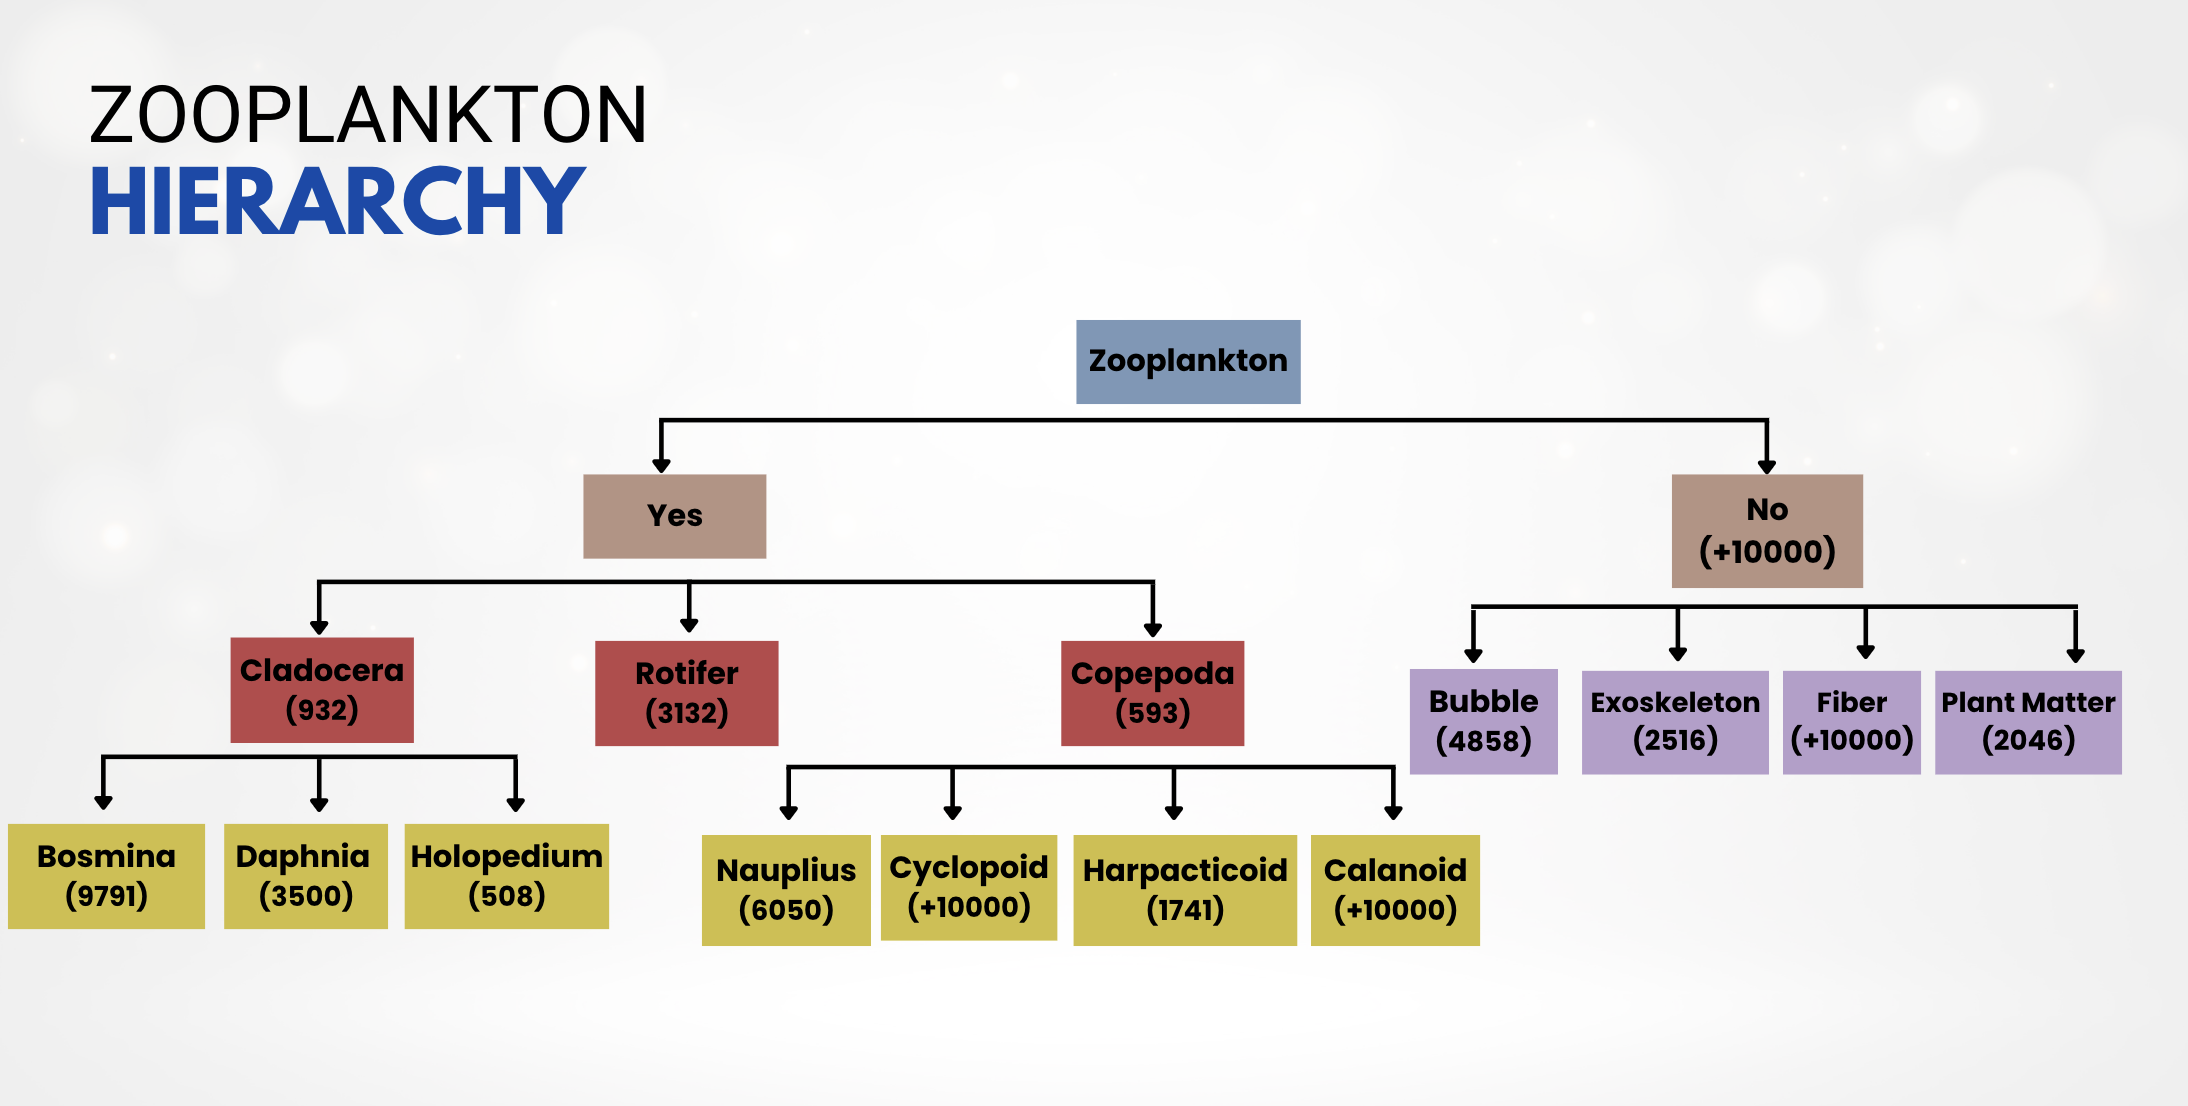

Some things to note:
- No hyperparemeter tuning has been done.
- This is using the smallest Resnet model with frozen weights.
- Not all classes and data has been used for this example.
- This uses standard Adam optimizer and Crossentropy loss. Other optimizers and losses should be considered.


In [50]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.models as models

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pad_sequence
from torchvision import transforms

from helpers import set_seed, ImageDataset


## Environment Setup

In [36]:
# Specify paths
data_directory = "../Zooplankton-Data"
data_subdirectories = ["Processed Data"]

# Specify other environment variables
SEED = 1
set_seed(SEED)


## Select Classes and Build Tree

In [37]:
# Define the list of zooplankton classes we want to classify
ZOOPLANKTON_CLASSES = [
    "Bosminidae",
    "Daphnia",
    # "Holopedium",
    "Rotifer",
    "Nauplius_Copepod",
    "Cyclopoid",
    "Harpacticoid",
    "Calanoid",
    "Bubbles",
    "Exoskeleton",
    "Fiber_Hairlike",
    "Fiber_Squiggly",
    "Plant_Matter",
]
NUM_CLASSES = len(ZOOPLANKTON_CLASSES)


In [38]:
# Define the hierarchical taxonomy structure mapping parents to children
TAXONOMY = {
    "Root": ["Yes", "No"],
    "Yes": ["Cladocera", "Rotifer_Group", "Copepoda"],
    "No": ["Bubble_Group", "Exoskeleton_Group", "Fiber", "Plant_Matter_Group"],
    "Cladocera": ["Bosminidae", "Daphnia"],
    "Copepoda": ["Calanoid", "Cyclopoid", "Harpacticoid", "Nauplius_Copepod"],
    "Rotifer_Group": ["Rotifer"],
    "Bubble_Group": ["Bubbles"],
    "Exoskeleton_Group": ["Exoskeleton"],
    "Fiber": ["Fiber_Hairlike", "Fiber_Squiggly"],
    "Plant_Matter_Group": ["Plant_Matter"],
}


In [39]:
# Build vocabulary and mapping from class names to their hierarchical paths
def build_hierarchy_tools(taxonomy, flat_classes):
    # Build vocabulary starting with special tokens
    vocab = {"<PAD>": 0, "<START>": 1, "<END>": 2}
    next_idx = 3

    for parent, children in taxonomy.items():
        if parent not in vocab:
            vocab[parent] = next_idx
            next_idx += 1
        for child in children:
            if child not in vocab:
                vocab[child] = next_idx
                next_idx += 1

    # Recursive helper to find the path from root to a target node
    def get_path(node, target, current_path):
        if node == target:
            return current_path
        if node in taxonomy:
            for child in taxonomy[node]:
                res = get_path(child, target, current_path + [child])
                if res:
                    return res
        return None

    # Create lookup table mapping class names to tensor paths
    class_to_path = {}
    for class_name in flat_classes:
        raw_path = get_path("Root", class_name, [])

        if raw_path is None:
            raise ValueError(f"Class '{class_name}' is missing from the TAXONOMY dict!")

        full_path = ["<START>", "Root"] + raw_path + ["<END>"]
        class_to_path[class_name] = torch.tensor(
            [vocab[n] for n in full_path], dtype=torch.long
        )

    return vocab, class_to_path


vocab, class_to_path_map = build_hierarchy_tools(TAXONOMY, ZOOPLANKTON_CLASSES)
TOTAL_NODES = len(vocab)
print(f"Total nodes in Neural Network: {TOTAL_NODES}")

# Custom collate function to batch images and pad hierarchical path sequences
def hierarchical_collate_fn(batch):
    images = []
    paths = []

    # Collect images and corresponding hierarchical paths
    for img, label_idx in batch:
        images.append(img)

        class_name = ZOOPLANKTON_CLASSES[label_idx]

        seq = class_to_path_map[class_name]
        paths.append(seq)

    images = torch.stack(images)

    # Stack images and pad paths to the same length
    paths_padded = pad_sequence(paths, batch_first=True, padding_value=0)

    return images, paths_padded


Total nodes in Neural Network: 25


## Build Dataset

In [40]:
# Define basic image transformations for resizing and normalization
basic_transforms = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ]
)

# Define augmentation pipeline for training data
aug_transforms = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(180),
    ]
)

NO_AUGMENT_CLASSES = ["Bubbles", "149um>"]

# Initialize the dataset with transforms and exclusions
dataset = ImageDataset(
    data_directory=data_directory,
    data_subdirectories=data_subdirectories,
    class_names=ZOOPLANKTON_CLASSES,
    max_class_size=15000,
    image_resolution=64,
    image_transforms=basic_transforms,
    aug_transforms=aug_transforms,
    ignore_classes=NO_AUGMENT_CLASSES,
    seed=SEED,
)

# Handle dataset targets if not directly accessible
try:
    all_labels = dataset.targets
except AttributeError:
    all_labels = [label for _, label in dataset]

# Split dataset into training and testing sets maintaining class distribution
train_split, test_split = train_test_split(
    np.arange(len(dataset)),
    test_size=0.2,
    stratify=all_labels,
    random_state=SEED,
)


train_labels = [dataset.labels[i] for i in train_split]

# Calculate class weights to handle class imbalance
class_counts = {}
for lab in train_labels:
    class_counts[lab] = class_counts.get(lab, 0) + 1

print("Training Set Counts:", class_counts)

weight_per_class = {}
for class_idx in range(NUM_CLASSES):
    count = class_counts.get(class_idx, 0)
    if count > 0:
        weight_per_class[class_idx] = 1.0 / count
    else:
        weight_per_class[class_idx] = 0.0
        print(f"Warning: Class Index {class_idx} has 0 training samples!")

train_sample_weights = [weight_per_class[lab] for lab in train_labels]
train_sample_weights = torch.DoubleTensor(train_sample_weights)

# Create a weighted sampler to oversample minority classes
sampler = torch.utils.data.WeightedRandomSampler(
    weights=train_sample_weights,
    num_samples=len(train_sample_weights),
    replacement=True,
)

# Create the training data loader with the custom collate function
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(dataset, train_split),
    batch_size=16,
    sampler=sampler,
    shuffle=False,
    collate_fn=hierarchical_collate_fn,
)

test_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(dataset, test_split),
    batch_size=64,
    shuffle=False,
    collate_fn=hierarchical_collate_fn,
)

Training Set Counts: {2: 1645, 6: 333, 3: 3766, 8: 898, 9: 4230, 10: 5164, 4: 1090, 1: 1921, 0: 2330, 11: 443, 5: 12, 7: 30}


## Model Definition and Setup

In [41]:
# Neural network combining a CNN encoder and RNN decoder for hierarchical classification
class HierarchicalCNNRNN(nn.Module):
    def __init__(self, num_classes, embed_size=128, hidden_size=512, num_layers=1):
        super(HierarchicalCNNRNN, self).__init__()

        # Use a pre-trained ResNet18 as the image encoder, freezing its weights
        resnet = models.resnet18(pretrained=True)
        for param in resnet.parameters():
            param.requires_grad = False
            
        
        modules = list(resnet.children())[:-1]
        self.cnn = nn.Sequential(*modules)

        # Project CNN features to match RNN hidden size
        self.cnn_to_rnn = nn.Linear(resnet.fc.in_features, hidden_size)

        # Embedding layer for label inputs
        self.embedding = nn.Embedding(num_classes, embed_size)

        # LSTM decoder to generate the hierarchy path
        self.rnn = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        # Output layer predicting the next node in the hierarchy
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, images, captions=None):
        batch_size = images.size(0)

        # Encode images to feature vectors
        with torch.no_grad():
            features = self.cnn(images)

        features = features.view(features.size(0), -1)

        # Initialize RNN hidden state with image features
        h_0 = self.cnn_to_rnn(features).unsqueeze(0)
        c_0 = torch.zeros_like(h_0)

        if captions is not None:
            # Training mode: use teacher forcing with provided captions
            embeddings = self.embedding(captions[:, :-1])

            outputs, _ = self.rnn(embeddings, (h_0, c_0))

            predictions = self.fc(outputs)
            return predictions

        else:
            # Inference mode: autoregressively predict the next node in the hierarchy
            start_token_index = 1

            start_token = torch.tensor(
                [start_token_index] * batch_size, device=images.device
            ).unsqueeze(1)

            inputs = self.embedding(start_token)
            hidden = (h_0, c_0)
            outputs = []

            max_depth = 5
            for _ in range(max_depth):
                out, hidden = self.rnn(inputs, hidden)
                prediction = self.fc(out)

                predicted_class = prediction.argmax(2)
                outputs.append(predicted_class)

                inputs = self.embedding(predicted_class)

            return torch.cat(outputs, dim=1)


model = HierarchicalCNNRNN(num_classes=NUM_CLASSES)

/Users/philiploewen/Desktop/school/UofT/Classes/STA2453/Zooplankton/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/philiploewen/Desktop/school/UofT/Classes/STA2453/Zooplankton/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [42]:
# Initialize model with total nodes in the vocabulary
model = HierarchicalCNNRNN(num_classes=TOTAL_NODES, hidden_size=256)

# Set up optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Use CrossEntropyLoss, ignoring padding tokens
criterion = nn.CrossEntropyLoss(ignore_index=0)

## Training Loop

In [43]:
# Main training loop iterating over epochs
NUM_EPOCHS = 5
print(f"Starting Training for {NUM_EPOCHS} epochs...")
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    for batch_idx, (images, captions) in enumerate(train_loader):
        # Move data to device
        images = images.to("cuda" if torch.cuda.is_available() else "cpu")
        captions = captions.to("cuda" if torch.cuda.is_available() else "cpu")

        # Forward pass
        outputs = model(images, captions)

        # Compute loss on flattened outputs
        outputs_flat = outputs.reshape(-1, TOTAL_NODES)
        targets_flat = captions[:, 1:].reshape(-1)

        loss = criterion(outputs_flat, targets_flat)

        # Backpropagation and optimization with gradient clipping
        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}], Loss: {avg_loss:.4f}")

Starting Training for 5 epochs...
Epoch [1/5], Loss: 0.6446
Epoch [2/5], Loss: 0.3138
Epoch [3/5], Loss: 0.2729
Epoch [4/5], Loss: 0.2555
Epoch [5/5], Loss: 0.2392


## Test Results

In [44]:
# Create reverse lookup for vocabulary
idx_to_word = {v: k for k, v in vocab.items()}

# Convert tensor indices back to a list of class names, handling special tokens
def decode_prediction(seq_tensor, idx_to_word):
    path = []
    for idx in seq_tensor:
        idx = idx.item()
        word = idx_to_word.get(idx, "<UNK>")

        if word == "<END>" or word == "<PAD>":
            break
        if word == "<START>":
            continue

        path.append(word)
    return path

In [45]:
# Run inference on the test set and compute classification metrics
def evaluate_model(model, loader, idx_to_word):
    # Run model in inference mode
    model.eval()

    y_true_leaves = []
    y_pred_leaves = []
    y_pred_paths = []

    print("Starting Evaluation...")

    with torch.no_grad():
        for images, captions in loader:

            preds = model(images, captions=None)

            # Decode ground truth and predicted paths to find the leaf nodes
            for i in range(len(images)):
                gt_path = decode_prediction(captions[i], idx_to_word)
                if not gt_path:
                    continue
                gt_leaf = gt_path[-1]

                pred_path = decode_prediction(preds[i], idx_to_word)

                if len(pred_path) < 1:
                    pred_leaf = "<EMPTY>"
                else:
                    pred_leaf = pred_path[-1]

                y_true_leaves.append(gt_leaf)
                y_pred_leaves.append(pred_leaf)
                y_pred_paths.append(pred_path)

    # Compute and print classification report
    print("\n--- Classification Report ---")
    print(classification_report(y_true_leaves, y_pred_leaves))

    return y_true_leaves, y_pred_leaves, y_pred_paths


true_labels, pred_labels, pred_paths = evaluate_model(model, test_loader, idx_to_word)

Starting Evaluation...

--- Classification Report ---
                  precision    recall  f1-score   support

      Bosminidae       0.57      0.56      0.57       582
         Bubbles       0.04      0.88      0.07         8
        Calanoid       0.18      0.51      0.26        83
       Cyclopoid       0.62      0.43      0.51       272
         Daphnia       0.82      0.50      0.62       480
     Exoskeleton       0.54      0.49      0.52       225
  Fiber_Hairlike       0.69      0.82      0.75      1058
  Fiber_Squiggly       0.79      0.56      0.66      1291
    Harpacticoid       0.01      0.67      0.02         3
Nauplius_Copepod       0.76      0.49      0.60       942
    Plant_Matter       0.25      0.86      0.39       111
         Rotifer       0.59      0.58      0.58       411

        accuracy                           0.59      5466
       macro avg       0.49      0.61      0.46      5466
    weighted avg       0.69      0.59      0.62      5466



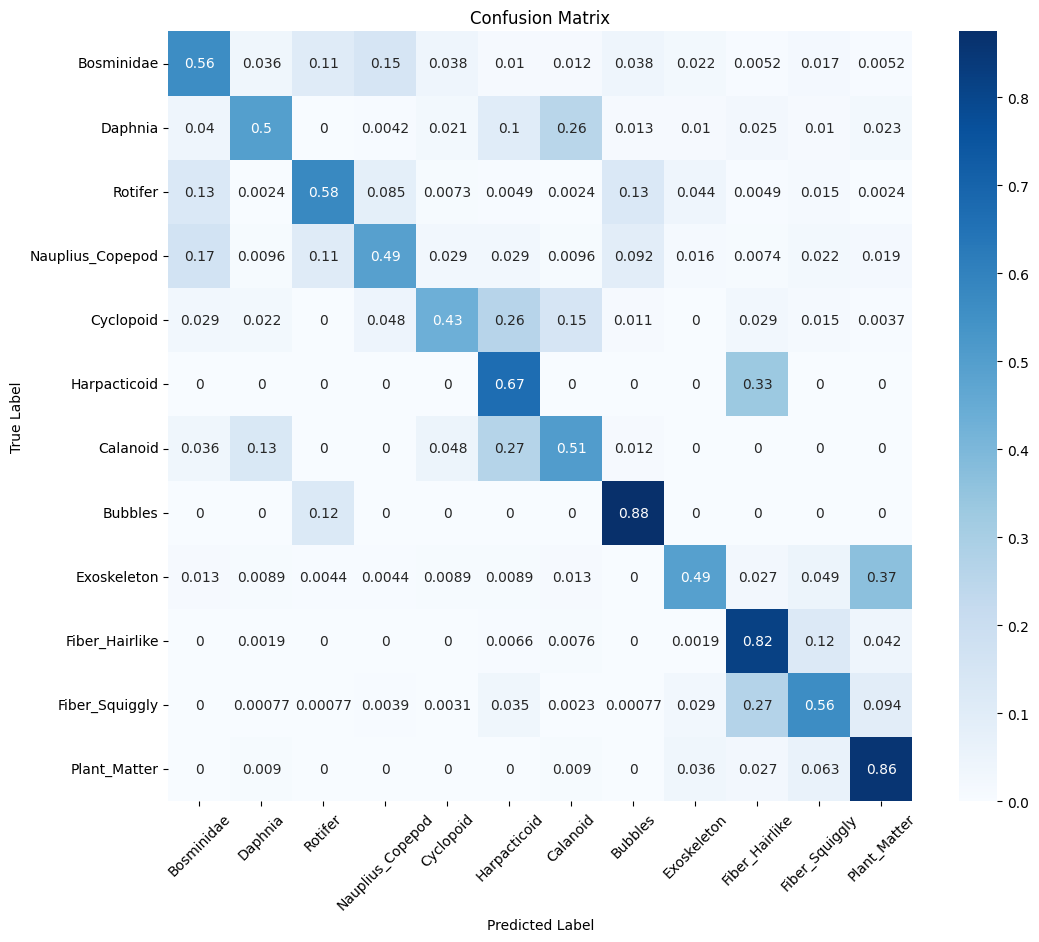

In [46]:
# Ensure predictions are available
if 'true_labels' not in locals() or 'pred_labels' not in locals():
    print("Running evaluation to get predictions...")
    true_labels, pred_labels = evaluate_model(model, test_loader, idx_to_word)

# Generate Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels, labels=ZOOPLANKTON_CLASSES, normalize='true')

# Plot Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    xticklabels=ZOOPLANKTON_CLASSES,
    yticklabels=ZOOPLANKTON_CLASSES,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

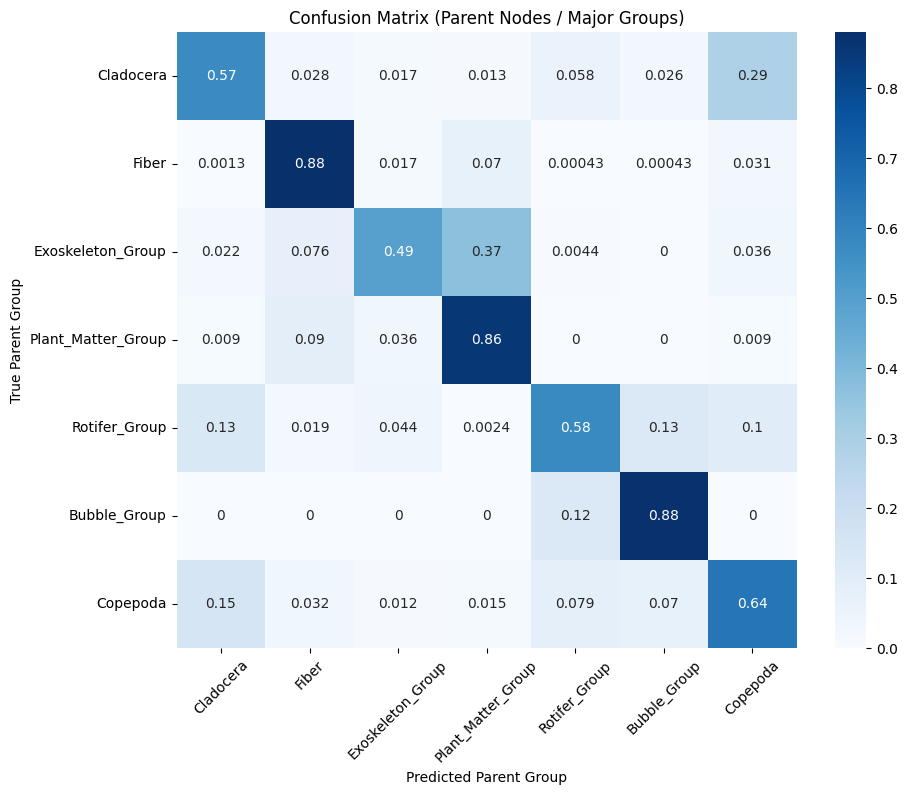

In [47]:
# Build a mapping from Leaf -> Immediate Parent (Major Group)
# We limit parents to those relevant to our valid leaves
valid_leaves = set(ZOOPLANKTON_CLASSES)
leaf_to_parent_map = {}

for parent, children in TAXONOMY.items():
    for child in children:
        if child in valid_leaves:
            leaf_to_parent_map[child] = parent

def get_parent_label(label):
    """Maps a label (leaf or otherwise) to its parent group if applicable."""
    return leaf_to_parent_map.get(label, label)

# Map predictions and ground truth to parents
true_parents = [get_parent_label(l) for l in true_labels]
# Note: pred_labels might contain things that are ALREADY parents if the hierarchy stopped early
pred_parents = [path[-2] for path in pred_paths]

# Get unique parent classes for the matrix
# Using set to get unique values, then sorting
parent_classes = list(set(true_parents + pred_parents))

# Generate Confusion Matrix
cm_parents = confusion_matrix(true_parents, pred_parents, labels=parent_classes, normalize='true')

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_parents,
    annot=True,
    cmap="Blues",
    xticklabels=parent_classes,
    yticklabels=parent_classes,
)
plt.xlabel("Predicted Parent Group")
plt.ylabel("True Parent Group")
plt.title("Confusion Matrix (Parent Nodes / Major Groups)")
plt.xticks(rotation=45)
plt.show()

In [48]:
print(classification_report(true_parents, pred_parents))

                    precision    recall  f1-score   support

      Bubble_Group       0.04      0.88      0.07         8
         Cladocera       0.70      0.57      0.63      1062
          Copepoda       0.66      0.64      0.65      1300
 Exoskeleton_Group       0.54      0.49      0.52       225
             Fiber       0.95      0.88      0.91      2349
Plant_Matter_Group       0.25      0.86      0.39       111
     Rotifer_Group       0.59      0.58      0.58       411

          accuracy                           0.72      5466
         macro avg       0.53      0.70      0.54      5466
      weighted avg       0.77      0.72      0.74      5466

